frame → latent → inferred action → policy → action
        ↑          ↑               ↑
      Model 0   Model 0         Model 1

# Data

## Split Videos into Images

We convert raw rollout videos into a dataset of frames:

$$
\text{video} \;\rightarrow\; \{x_1, x_2, \dots, x_T\}, 
\quad x_t \in \mathbb{R}^{1 \times 84 \times 84}
$$

Each frame is processed as:

$$
x_t = \text{Resize}_{84 \times 84}\big(\text{Gray}(frame_t)\big)
$$

Frames are stored per episode:

$$
\text{data/frames}/e/\{x_1, x_2, \dots, x_T\}
$$

From this, we construct a dataset of transition pairs:

$$
\mathcal{D} = \{(x_t, x_{t+1})\}
$$

The dataset is then serialized:

$$
\mathcal{D} \;\rightarrow\; \text{data/dataset/dataset.pt}
$$

This removes video decoding overhead and ensures fast, consistent tensor inputs during training.


In [8]:
# import cv2
# import os

# VIDEO_DIR = "../Donor/videos"
# SAVE_DIR = "data/frames"

# # ustaw cwd tylko jeśli odpalasz jako .py
# if "__file__" in globals():
#     os.chdir(os.path.dirname(os.path.abspath(__file__)))

# os.makedirs(SAVE_DIR, exist_ok=True)

# video_files = sorted([f for f in os.listdir(VIDEO_DIR) if f.endswith(".mp4")])

# for vid_idx, video_name in enumerate(video_files):

#     print(f"[PROCESSING] {video_name}")

#     video_path = os.path.join(VIDEO_DIR, video_name)
#     cap = cv2.VideoCapture(video_path)

#     episode_dir = os.path.join(SAVE_DIR, str(vid_idx))
#     os.makedirs(episode_dir, exist_ok=True)

#     frame_id = 0

#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break

#         frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#         frame = cv2.resize(frame, (84, 84))

#         save_path = os.path.join(episode_dir, f"{frame_id}.png")
#         cv2.imwrite(save_path, frame)

#         frame_id += 1

#     cap.release()

#     print(f"[DONE] episode {vid_idx} → {frame_id} frames")

# print("ALL DONE")

## Dataset

We convert raw rollout videos into two datasets: train and test.

$$
\text{video} \;\rightarrow\; \{x_1, x_2, \dots, x_T\}, \quad x_t \in \mathbb{R}^{1 \times 84 \times 84}
$$

Each frame is processed as:

$$
x_t = \text{Resize}_{84 \times 84}\big(\text{Gray}(frame_t)\big)
$$

Frames are stored per episode:

train:
$$
\text{data/datasets/train}/e/\{x_1, x_2, \dots, x_T\}
$$

test:
$$
\text{data/datasets/test}/e/\{x_1, x_2, \dots, x_T\}
$$

From this, we construct transition pairs:

$$
\mathcal{D}_{\text{train}} = \{(x_t, x_{t+1})\}
$$

$$
\mathcal{D}_{\text{test}} = \{(x_t, x_{t+1})\}
$$

Datasets are serialized:

$$
\mathcal{D}_{\text{train}} \rightarrow \text{data/dataset/train.pt}
$$

$$
\mathcal{D}_{\text{test}} \rightarrow \text{data/dataset/test.pt}
$$

This removes video decoding overhead and ensures fast, consistent tensor inputs during training and evaluation.

## Create

In [9]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import random

if "__file__" in globals():
    os.chdir(os.path.dirname(os.path.abspath(__file__)))


class VideoDataset(Dataset):
    def __init__(self, input_dir, episodes, output_path=None):
        self.samples = []
        self.transform = T.ToTensor()

        total_pairs = 0

        for episode in episodes:
            episode_path = os.path.join(input_dir, episode)

            if not os.path.isdir(episode_path):
                continue

            frames = sorted(
                os.listdir(episode_path),
                key=lambda x: int(x.split(".")[0])
            )

            num_pairs = len(frames) - 1

            for i in range(num_pairs):
                f1 = os.path.join(episode_path, frames[i])
                f2 = os.path.join(episode_path, frames[i+1])

                x_t  = Image.open(f1).convert("L")
                x_t1 = Image.open(f2).convert("L")

                x_t  = self.transform(x_t)
                x_t1 = self.transform(x_t1)

                self.samples.append((x_t, x_t1))

            total_pairs += num_pairs
            print(f"[DATASET] episode {episode} → {num_pairs} pairs")

        print(f"[DATASET] total pairs: {total_pairs}")

        if output_path is not None:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            torch.save(self.samples, output_path)
            print(f"[SAVED] dataset → {output_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# split episodes
FRAMES_DIR = "data/frames"
episodes = sorted(os.listdir(FRAMES_DIR))

random.shuffle(episodes)
split_idx = int(0.8 * len(episodes))

train_eps = episodes[:split_idx]
test_eps  = episodes[split_idx:]

# create datasets
train_dataset = VideoDataset(
    FRAMES_DIR,
    train_eps,
    output_path="data/datasets/train.pt"
)

test_dataset = VideoDataset(
    FRAMES_DIR,
    test_eps,
    output_path="data/datasets/test.pt"
)

[DATASET] episode 17 → 708 pairs
[DATASET] episode 11 → 691 pairs
[DATASET] episode 10 → 671 pairs
[DATASET] episode 3 → 685 pairs
[DATASET] episode 1 → 713 pairs
[DATASET] episode 5 → 615 pairs
[DATASET] episode 2 → 773 pairs
[DATASET] episode 12 → 738 pairs
[DATASET] episode 9 → 583 pairs
[DATASET] episode 14 → 545 pairs
[DATASET] episode 8 → 552 pairs
[DATASET] episode 15 → 693 pairs
[DATASET] episode 0 → 906 pairs
[DATASET] episode 13 → 558 pairs
[DATASET] episode 7 → 677 pairs
[DATASET] episode 16 → 581 pairs
[DATASET] total pairs: 10689
[SAVED] dataset → data/datasets/train.pt
[DATASET] episode 4 → 726 pairs
[DATASET] episode 18 → 663 pairs
[DATASET] episode 19 → 701 pairs
[DATASET] episode 6 → 882 pairs
[DATASET] total pairs: 2972
[SAVED] dataset → data/datasets/test.pt


## Import

In [10]:
import torch
from torch.utils.data import Dataset

class DownloadVideoDataset(Dataset):
    def __init__(self, dataset_path):
        print(f"[LOADING] {dataset_path}")
        self.samples = torch.load(dataset_path)
        print(f"[LOADED] {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [11]:
train_dataset = DownloadVideoDataset("data/datasets/train.pt")
test_dataset = DownloadVideoDataset("data/datasets/test.pt")

[LOADING] data/datasets/train.pt
[LOADED] 10689 samples
[LOADING] data/datasets/test.pt
[LOADED] 2972 samples


## Explore

In [12]:
from IPython.display import display, Math

display(Math(f"We\\ have\\ {len(train_dataset)}\\ train\\ dataset\\ tuples:\\ (x_t, x_{{t+1}})"))
display(Math(f"We\\ have\\ {len(test_dataset)}\\ test\\ dataset\\ tuples:\\ (x_t, x_{{t+1}})"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

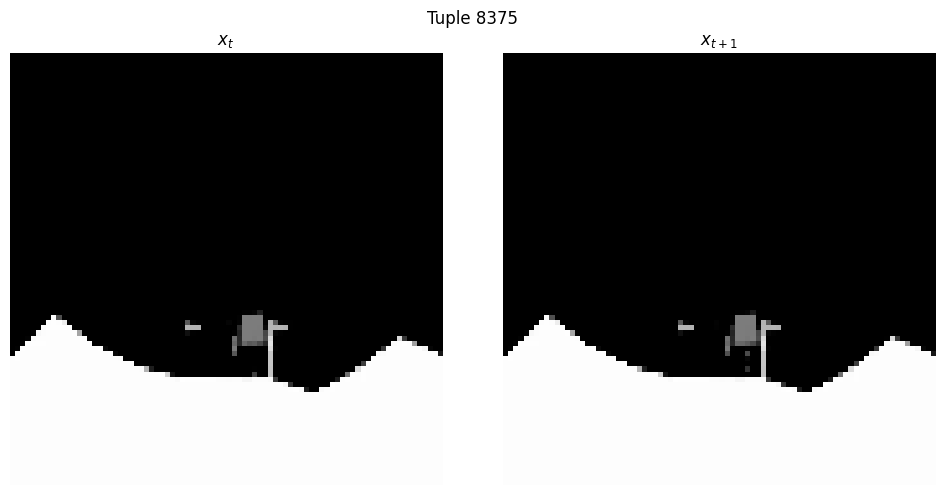

In [13]:
import numpy as np
import matplotlib.pyplot as plt

rand_img = np.random.randint(len(train_dataset))

x_t0 = train_dataset[rand_img][0]
x_t1 = train_dataset[rand_img][1]

fig, axs = plt.subplots(1,2,figsize= (10,5))

axs[0].imshow(x_t0.squeeze(), cmap = 'grey')
axs[0].set_title('$x_t$')
axs[1].imshow(x_t1.squeeze(), cmap = 'grey')
axs[1].set_title('$x_{t+1}$')

for i in range(2):
    axs[i].axis(False)

plt.suptitle(f'Tuple {rand_img}')
plt.tight_layout()
plt.show()

## DataLoader

In [14]:
from torch.utils.data import DataLoader

def get_dataloaders(train_dataset, test_dataset, batch_size=64, num_workers=0):
    print(f"[DATALOADER] batch_size={batch_size}")

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,  # we can shuffle because we use pairs (x_t0, x_t1) not RNN, its simple Markov Decision Process
        num_workers=num_workers,
        pin_memory=True
    )

    test_dataloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_dataloader, test_dataloader

In [15]:
train_dataloader, test_dataloader = get_dataloaders(train_dataset, test_dataset)

for x_t, x_t1 in train_dataloader:
    print(x_t.shape)
    break

[DATALOADER] batch_size=64
torch.Size([64, 1, 84, 84])


/Users/adriankazi/miniconda3/envs/dl-video-learning/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


# Model 0

## Intro

Model 0 is to see if we can successfully predict next frame. Model 0 includes:

* state representation - $x_t \text{ frame} \rightarrow z_t \text{ latent}$
* dynamics             - $z_t \text{ latent }_t \rightarrow z_{t+1} \text{ latent }_{t+1}$
* reconstruction       - $z_t \text{ latent} \rightarrow x_t \text{ frame} $  

To put it simply Model 0 learns how world works from frames.

Model Input: $(x_t, x_{t+1})$

Model Output: 

$$z_{t+1}        = f(x_{t+1})       \text{ (true latent)}$$
$$z_{t+1}^{hat}  = h(z_t, a_t)       \text{ (predicted latent)}$$
$$x_{t+1}^{hat}  = d(z_{t+1}^{hat})  \text{ (predicted frame)} $$
$$x_{t+1}^{recon}= d(z_{t+1})        \text{ (reconstruction)} $$

## Math

$x_t$ is a single video frame (image at time t)

$$
z_t = f_{\theta}(x_t)
$$

$f_{\theta}$ = CNN encoder (neural network with parameters $\theta$)  
*Input:* image $x_t$  
*Output:* latent vector $z_t$ (compressed numeric representation of the frame)

---

$$
z_{t+1} = f_{\theta}(x_{t+1})
$$

Same CNN encoder  
*Input:* next image $x_{t+1}$  
*Output:* true next latent representation $z_{t+1}$

---

$$
\hat{a}_t = g_{\phi}(z_t, z_{t+1})
$$

$g_{\phi}$ = Action Inference Network (MLP with parameters $\phi$)  
*Input:* current latent $z_t$ and next latent $z_{t+1}$  
*Output:* inferred action $\hat{a}_t$ that best explains transition

---

$$
\hat{z}_{t+1} = h_{\psi}(z_t, \hat{a}_t)
$$

$h_{\psi}$ = Dynamics model (MLP or RNN with parameters $\psi$)  
*Input:* current latent $z_t$ and inferred action $\hat{a}_t$  
*Output:* predicted next latent $\hat{z}_{t+1}$

---

$$
\hat{x}_{t+1} = d_{\omega}(\hat{z}_{t+1})
$$

$d_{\omega}$ = Decoder network (neural network with parameters $\omega$)  
*Input:* predicted latent $\hat{z}_{t+1}$  
*Output:* predicted next image $\hat{x}_{t+1}$

---

$$
L_{pixel}^{dyn} = \| x_{t+1} - \hat{x}_{t+1} \|^2
$$

Pixel reconstruction loss from dynamics  
*Input:* true frame $x_{t+1}$ and predicted frame $\hat{x}_{t+1} = d_{\omega}(\hat{z}_{t+1})$  
*Output:* scalar reconstruction error

---

$$
L_{pixel}^{ae} = \| x_{t+1} - \tilde{x}_{t+1} \|^2
$$

Autoencoder reconstruction loss (MSE)  
*Input:* true frame $x_{t+1}$ and reconstructed frame $\tilde{x}_{t+1} = d_{\omega}(z_{t+1})$  
*Output:* scalar reconstruction error

---

$$
L_{latent} = \| z_{t+1} - \hat{z}_{t+1} \|^2
$$

Latent consistency loss (MSE)  
*Input:* true latent $z_{t+1}$ and predicted latent $\hat{z}_{t+1}$  
*Output:* scalar latent error

---

$$
L = L_{pixel}^{dyn} + \alpha L_{latent} + \beta L_{pixel}^{ae}
$$

Total training loss minimized during learning

## Code

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WorldModel(nn.Module):
    def __init__(self, z_dim=128, a_dim=2):
        super().__init__()

        # f_theta (encoder)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*8*8, z_dim)
        )

        # g_phi (inverse dynamics)
        self.inverse = nn.Sequential(
            nn.Linear(z_dim*2, 256),
            nn.ReLU(),
            nn.Linear(256, a_dim)
        )

        # h_psi (forward dynamics)
        self.dynamics = nn.Sequential(
            nn.Linear(z_dim + a_dim, 256),
            nn.ReLU(),
            nn.Linear(256, z_dim)
        )

        # d_omega (decoder)
        self.decoder_fc = nn.Linear(z_dim, 128*8*8)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 10, stride=2)
        )

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 128, 8, 8)
        x = self.decoder_conv(x)

        return x

    def forward(self, x_t, x_t1):
        # encode
        z_t  = self.encoder(x_t)
        z_t1 = self.encoder(x_t1)

        # inverse dynamics
        a_t = self.inverse(torch.cat([z_t, z_t1], dim=1))

        # forward dynamics
        z_t1_hat = self.dynamics(torch.cat([z_t, a_t], dim=1))

        # decode
        x_t1_hat   = self.decode(z_t1_hat)  # from dynamics
        x_t1_recon = self.decode(z_t1)      # autoencoder

        # z_t1        - true latent of x_t1 (encoder output)
        # z_t1_hat    - predicted latent from dynamics model
        # x_t1_hat    - predicted frame from z_t1_hat (future prediction)
        # x_t1_recon  - reconstructed frame from z_t1 (autoencoder path)
        # a_t         - action inferred from current frame - that leads to x_t1

        return z_t1, z_t1_hat, x_t1_hat, x_t1_recon, a_t


def loss_fn(x_t1, x_t1_hat, x_t1_recon, z_t1, z_t1_hat, alpha=1.0, beta=1.0):
    L_pixel_dyn = F.mse_loss(x_t1_hat, x_t1)
    L_pixel_ae  = F.mse_loss(x_t1_recon, x_t1)
    L_latent    = F.mse_loss(z_t1_hat, z_t1)

    L = L_pixel_dyn + alpha * L_latent + beta * L_pixel_ae

    return L, L_pixel_dyn, L_latent, L_pixel_ae

## Debug Spin

In [17]:
model0 = WorldModel()
model0.train()

# 1 batch
x_t0, x_t1 = next(iter(train_dataloader))

# forward
z_t1, z_t1_hat, x_t1_hat, x_t1_recon, a_t = model0(x_t0, x_t1)

# loss
L, L_dyn, L_latent, L_ae = loss_fn(x_t1, x_t1_hat, x_t1_recon, z_t1, z_t1_hat)

print("SHAPES:")
print("x_t0:      ",x_t0.shape)
print("x_t1:      ", x_t1.shape)
print("x_t1_hat:  ",x_t1_hat.shape)
print("x_t1_recon:",x_t1_recon.shape)
print("a_t:       ", a_t.shape)

print('\nLOSSES:')
print(f"Total:     {L.item():.4f}")
print(f"Pixel dyn: {L_dyn.item():.4f}")
print(f"Latent:    {L_latent.item():.4f}")
print(f"Pixel AE:  {L_ae.item():.4f}")


SHAPES:
x_t0:       torch.Size([64, 1, 84, 84])
x_t1:       torch.Size([64, 1, 84, 84])
x_t1_hat:   torch.Size([64, 1, 84, 84])
x_t1_recon: torch.Size([64, 1, 84, 84])
a_t:        torch.Size([64, 2])

LOSSES:
Total:     0.6203
Pixel dyn: 0.3090
Latent:    0.0022
Pixel AE:  0.3090


## Loss Test Spin

In [18]:
import torch

model0 = WorldModel()
optimizer0 = torch.optim.Adam(model0.parameters(), lr=1e-3)

model0.train()

num_epochs = 3
num_steps = len(train_dataloader)

loss_total  = torch.zeros(num_epochs, num_steps)
loss_dyn    = torch.zeros(num_epochs, num_steps)
loss_latent = torch.zeros(num_epochs, num_steps)
loss_ae     = torch.zeros(num_epochs, num_steps)

for epoch in range(num_epochs):

    for i, (x_t, x_t1) in enumerate(train_dataloader):

        optimizer0.zero_grad()

        z_t1, z_t1_hat, x_t1_hat, x_t1_recon, a_t = model0(x_t, x_t1)

        L, L_dyn, L_latent, L_ae = loss_fn(
            x_t1, x_t1_hat, x_t1_recon, z_t1, z_t1_hat
        )

        L.backward()
        optimizer0.step()

        loss_total[epoch, i]  = L.detach()
        loss_dyn[epoch, i]    = L_dyn.detach()
        loss_latent[epoch, i] = L_latent.detach()
        loss_ae[epoch, i]     = L_ae.detach()

        if i % 50 == 0:
            print(f"Epoch {epoch} | Step {i:>4} | Loss {L.item():.4f}")

Epoch 0 | Step    0 | Loss 0.4569
Epoch 0 | Step   50 | Loss 0.0550
Epoch 0 | Step  100 | Loss 0.0280
Epoch 0 | Step  150 | Loss 0.0152
Epoch 1 | Step    0 | Loss 0.0132
Epoch 1 | Step   50 | Loss 0.0096
Epoch 1 | Step  100 | Loss 0.0077
Epoch 1 | Step  150 | Loss 0.0061
Epoch 2 | Step    0 | Loss 0.0063
Epoch 2 | Step   50 | Loss 0.0052
Epoch 2 | Step  100 | Loss 0.0044
Epoch 2 | Step  150 | Loss 0.0040


## Loss Plots

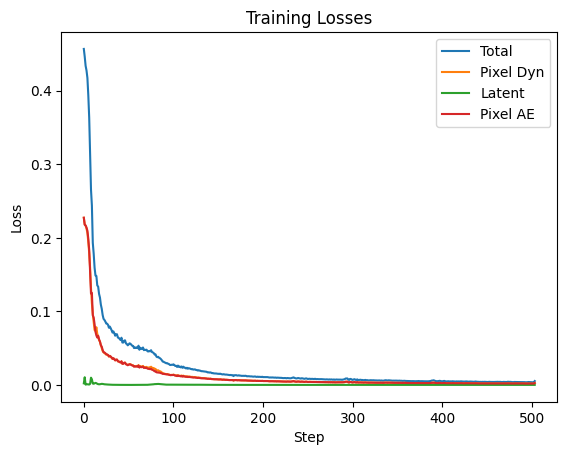

In [19]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(loss_total.view(-1),  label="Total")
plt.plot(loss_dyn.view(-1),    label="Pixel Dyn")
plt.plot(loss_latent.view(-1), label="Latent")
plt.plot(loss_ae.view(-1),     label="Pixel AE")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.show()

## Predictions

In [20]:
model0.eval()

total_loss = 0
count = 0

with torch.no_grad():
    for x_t, x_t1 in test_dataloader:

        z_t  = model0.encoder(x_t)
        z_t1 = model0.encoder(x_t1)

        a_hat = model0.inverse(torch.cat([z_t, z_t1], dim=1))

        loss = (a_hat ** 2).mean()

        total_loss += loss.item()
        count += 1

print("Test MSE proxy:", total_loss / count)

Test MSE proxy: 1.1901710388508249


## Storage (Z, A)

If we're satisfied with MSE we save Z, A in storage for policy training

In [21]:
model0.eval()

all_z = []
all_a = []

with torch.no_grad():
    for x_t, x_t1 in test_dataloader:

        z_t  = model0.encoder(x_t)
        z_t1 = model0.encoder(x_t1)

        a_hat = model0.inverse(torch.cat([z_t, z_t1], dim=1))

        all_z.append(z_t.cpu())
        all_a.append(a_hat.cpu())

Z = torch.cat(all_z)
A = torch.cat(all_a)

torch.save((Z, A), "data/datasets/policy_dataset.pt")

print("Saved:", Z.shape, A.shape)

Saved: torch.Size([2972, 128]) torch.Size([2972, 2])


# Model 1

## Intro

Model 1 is responsible for decision-making. While Model 0 learns how the world works, Model 1 learns what action to take given the current state.

## Math



Model 1 takes as input the latent state produced by Model 0:

$$
z_t = f_{\theta}(x_t)
$$

and outputs an action:

$$
a_t = \pi_{\phi}(z_t)
$$

where $\pi_{\phi}$ is the policy network, which is exactly our model. This is the same policy $\pi$ that can be trained via traditional reinforcement learning; here, however, it operates on the latent state produced by Model 0.

The goal of Model 1 is to map the current state to an action that leads to desirable future outcomes.

In contrast to Model 0, which is trained in a self-supervised way, Model 1 requires a learning signal related to performance (e.g., reward).

## Code

In [22]:
import torch
import torch.nn as nn

class LatentPolicy(nn.Module):
    def __init__(self, z_dim=128, action_dim=2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Tanh()  # action ∈ [-1,1]
        )

    def forward(self, z):
        return self.net(z)

## Policy Train

In [23]:
import os
from datetime import datetime
import torch

policy = LatentPolicy()
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

dataset = torch.load("data/datasets/policy_dataset.pt")
Z, A = dataset

for epoch in range(5):

    pred = policy(Z)
    loss = ((pred - A)**2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch} | Loss {loss.item():.4f}")

# ave
os.makedirs("policies", exist_ok=True)
timestamp = datetime.now().strftime("%d%m%Y_%H%M%S")
save_path = f"policies/policy_{timestamp}.pth"

torch.save(policy.state_dict(), save_path)

print(f"[SAVED] {save_path}")

Epoch 0 | Loss 1.3045
Epoch 1 | Loss 1.2377
Epoch 2 | Loss 1.1777
Epoch 3 | Loss 1.1243
Epoch 4 | Loss 1.0769
[SAVED] policies/policy_21032026_203630.pth


## Debug Spin

In [24]:
import torch

policy = LatentPolicy()

# load policy
policy.load_state_dict(torch.load(f"policies/policy_{timestamp}.pth"))
policy.eval()

x_t = torch.randn(1,1,84,84)

z_t = model0.encoder(x_t)
a_t = policy(z_t)

print(a_t.shape)  # (1,2)

torch.Size([1, 2])


## Loss Test Spin

Since we don't have action_true we can't test loss. Model1 is simply transfer Model0 to action on fly.

# Lunar Lander

In [25]:
import numpy as np

class RandomPolicy:
    def __init__(self, action_dim=2):
        self.action_dim = action_dim

    def __call__(self, state):
        return np.random.uniform(-1, 1, size=(self.action_dim,)).astype(np.float32)
        # return model(state)

In [28]:
import gymnasium as gym
import numpy as np
import torch
import cv2

def preprocess(frame):
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    frame = cv2.resize(frame, (84, 84))
    frame = torch.tensor(frame, dtype=torch.float32) / 255.0
    return frame.unsqueeze(0).unsqueeze(0)


class LunarLanderRunner:
    def __init__(self, model0, policy):
        self.env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
        self.encoder = model0.encoder
        self.policy = policy

    def run(self, episodes=3):
        self.encoder.eval()
        self.policy.eval()

        for ep in range(episodes):

            state, _ = self.env.reset()
            done = False
            total_reward = 0

            while not done:

                frame = self.env.render()
                cv2.imshow("env", frame)
                cv2.waitKey(1)

                x_t = preprocess(frame)

                with torch.no_grad():
                    z_t = self.encoder(x_t)
                    action = self.policy(z_t)

                action = action.squeeze().cpu().numpy()

                state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                total_reward += reward

            print(f"Episode {ep} | Reward: {total_reward:.2f}")

        self.env.close()
        cv2.destroyAllWindows()

In [34]:
# RANDOM POLICY
# policy = RandomPolicy()

# TRAINED POLICY
policy = LatentPolicy()
policy.load_state_dict(torch.load(f"policies/policy_{timestamp}.pth"))
print(f"Using policy_{timestamp}.pth\n\n")
runner = LunarLanderRunner(model0, policy)

runner.run(episodes=3)

Using policy_21032026_203630.pth


Episode 0 | Reward: -381.58
Episode 1 | Reward: -150.97
Episode 2 | Reward: -387.39
